# Analysis of  the training results

## Overview

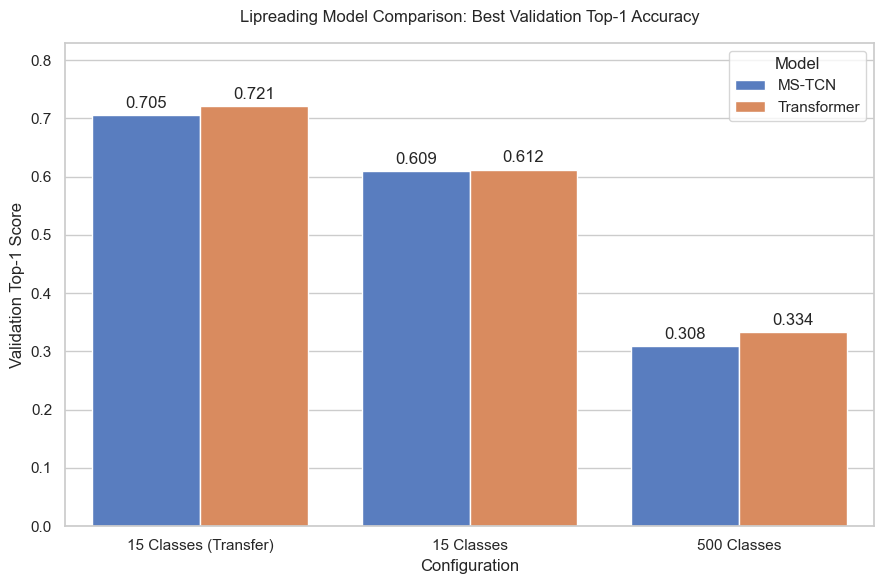

Model                  MS-TCN  Transformer
Dataset / Epochs                          
15 Classes              0.609        0.612
15 Classes (Transfer)   0.705        0.721
500 Classes             0.308        0.334


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df_mstcn_15 = pd.read_csv(
    r"C:\Users\pstay\code\BWKI\lipreading\mstcn_baseline\checkpoints_15\metrics.csv"
)
df_transformer_15 = pd.read_csv(
    r"C:\Users\pstay\code\BWKI\lipreading\transformer_based\checkpoints_15\metrics.csv"
)
df_mstcn_500 = pd.read_csv(
    r"C:\Users\pstay\code\BWKI\lipreading\mstcn_baseline\checkpoints\metrics.csv"
)
df_transformer_500 = pd.read_csv(
    r"C:\Users\pstay\code\BWKI\lipreading\transformer_based\checkpoints\metrics.csv"
)
df_mstcn_transfer = pd.read_csv(
    r"C:\Users\pstay\code\BWKI\lipreading\mstcn_baseline\checkpoints_15_transfer\metrics.csv"
)
df_transformer_transfer = pd.read_csv(
    r"C:\Users\pstay\code\BWKI\lipreading\transformer_based\checkpoints_15_transfer\metrics.csv"
)

best_mstcn_15 = df_mstcn_15.loc[df_mstcn_15["val_top1"].idxmax()]
best_transformer_15 = df_transformer_15.loc[
    df_transformer_15["val_top1"].idxmax()
]
best_mstcn_500 = df_mstcn_500.loc[df_mstcn_500["val_top1"].idxmax()]
best_transformer_500 = df_transformer_500.loc[
    df_transformer_500["val_top1"].idxmax()
]
best_mstcn_transfer = df_mstcn_transfer.loc[
    df_mstcn_transfer["val_top1"].idxmax()
]
best_transformer_transfer = df_transformer_transfer.loc[
    df_transformer_transfer["val_top1"].idxmax()
]

plot_data = pd.DataFrame(
    {
        "Model": [
            "MS-TCN",
            "Transformer",
            "MS-TCN",
            "Transformer",
            "MS-TCN",
            "Transformer",
        ],
        "Dataset / Epochs": [
            "15 Classes (Transfer)",
            "15 Classes (Transfer)",
            "15 Classes",
            "15 Classes",
            "500 Classes",
            "500 Classes",
        ],
        "Best Val Top-1": [
            best_mstcn_transfer["val_top1"],
            best_transformer_transfer["val_top1"],
            best_mstcn_15["val_top1"],
            best_transformer_15["val_top1"],
            best_mstcn_500["val_top1"],
            best_transformer_500["val_top1"],
        ],
    }
)

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=plot_data,
    x="Dataset / Epochs",
    y="Best Val Top-1",
    hue="Model",
    palette="muted",
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.title("Lipreading Model Comparison: Best Validation Top-1 Accuracy", pad=15)
plt.ylabel("Validation Top-1 Score")
plt.xlabel("Configuration")

max_val = plot_data["Best Val Top-1"].max()
plt.ylim(0, min(1.0, max_val * 1.15))

plt.tight_layout()
plt.show()

# table of results
print(plot_data.pivot(index="Dataset / Epochs", columns="Model", values="Best Val Top-1").to_string(float_format="{:.3f}".format))

## 15 Word comparison: MS-TCN vs. Transformer-based

In [ ]:
# one standard (default cycle) colour per model; top-1 solid, top-5 dashed
MSTCN_COLOR = "C0"
TRANSFORMER_COLOR = "C1"

fig, (ax_val, ax_train) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
fig.suptitle("15-Word Classification: MS-TCN vs. Transformer-based", fontsize=16, fontweight="bold")

# --- left: validation accuracy ---
ax_val.plot(df_mstcn_15['epoch'], df_mstcn_15["val_top1"] * 100, label="MS-TCN", color=MSTCN_COLOR)
ax_val.plot(df_transformer_15['epoch'], df_transformer_15["val_top1"] * 100, label="Transformer-based", color=TRANSFORMER_COLOR)
ax_val.plot(df_mstcn_15['epoch'], df_mstcn_15["val_top5"] * 100, label="MS-TCN (top-5)", linestyle="--", color=MSTCN_COLOR)
ax_val.plot(df_transformer_15['epoch'], df_transformer_15["val_top5"] * 100, label="Transformer-based (top-5)", linestyle="--", color=TRANSFORMER_COLOR)

# mark the maximum top-1 accuracy of each model: black marker + black text on a
# filled box with the curve colour as its border
for df, color, off in ((df_mstcn_15, MSTCN_COLOR, (10, -20)), (df_transformer_15, TRANSFORMER_COLOR, (10, 10))):
    pk = df["val_top1"].idxmax()
    pe, pv = df["epoch"][pk], df["val_top1"][pk] * 100
    ax_val.scatter([pe], [pv], color="black", zorder=6, s=55)
    ax_val.annotate(f"max {pv:.1f}% @ ep{int(pe)}", (pe, pv), textcoords="offset points",
                    xytext=off, fontsize=10, fontweight="bold", color="black", zorder=6,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor=color, linewidth=1.2, alpha=0.95))

ax_val.set_title('Validation Accuracy')
ax_val.legend()
ax_val.set_ylabel('Accuracy (%)')
ax_val.set_xlabel('Epoch')
ax_val.grid(True)

# --- right: train accuracy (same per-model colours) ---
ax_train.plot(df_mstcn_15['epoch'], df_mstcn_15["train_acc"] * 100, label="MS-TCN", color=MSTCN_COLOR)
ax_train.plot(df_transformer_15['epoch'], df_transformer_15["train_acc"] * 100, label="Transformer-based", color=TRANSFORMER_COLOR)

for df, color, off in ((df_mstcn_15, MSTCN_COLOR, (10, -20)), (df_transformer_15, TRANSFORMER_COLOR, (10, 10))):
    pk = df["train_acc"].idxmax()
    pe, pv = df["epoch"][pk], df["train_acc"][pk] * 100
    ax_train.scatter([pe], [pv], color="black", zorder=6, s=55)
    ax_train.annotate(f"max {pv:.1f}% @ ep{int(pe)}", (pe, pv), textcoords="offset points",
                      xytext=off, fontsize=10, fontweight="bold", color="black", zorder=6,
                      bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                                edgecolor=color, linewidth=1.2, alpha=0.95))

ax_train.set_title('Train Accuracy over Epochs')
ax_train.legend()
ax_train.set_xlabel('Epoch')
ax_train.grid(True)

for ax in (ax_val, ax_train):
    ax.set_ylim(0, 100)
    ax.set_xlim(0, 80)
    ax.set_xticks(np.arange(0, 80, 10))
    ax.set_yticks(np.arange(0, 100, 10))

plt.tight_layout()

## 500 Word comparison: MS-TCN vs. Transformer-based

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# one standard (default cycle) colour per model; top-1 solid, top-5 dashed
MSTCN_COLOR = "C0"
TRANSFORMER_COLOR = "C1"

fig, (ax_val, ax_train) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
fig.suptitle("500-Word Classification: MS-TCN vs. Transformer-based", fontsize=16, fontweight="bold")

# --- left: validation accuracy ---
ax_val.plot(df_mstcn_500['epoch'], df_mstcn_500["val_top1"] * 100, label="MS-TCN", color=MSTCN_COLOR)
ax_val.plot(df_transformer_500['epoch'], df_transformer_500["val_top1"] * 100, label="Transformer-based", color=TRANSFORMER_COLOR)
ax_val.plot(df_mstcn_500['epoch'], df_mstcn_500["val_top5"] * 100, label="MS-TCN (top-5)", linestyle="--", color=MSTCN_COLOR)
ax_val.plot(df_transformer_500['epoch'], df_transformer_500["val_top5"] * 100, label="Transformer-based (top-5)", linestyle="--", color=TRANSFORMER_COLOR)

# mark the maximum top-1 accuracy of each model: black marker + black text on a
# filled box with the curve colour as its border
for df, color, off in ((df_mstcn_500, MSTCN_COLOR, (10, -20)), (df_transformer_500, TRANSFORMER_COLOR, (10, 10))):
    pk = df["val_top1"].idxmax()
    pe, pv = df["epoch"][pk], df["val_top1"][pk] * 100
    ax_val.scatter([pe], [pv], color="black", zorder=6, s=55)
    ax_val.annotate(f"max {pv:.1f}% @ ep{int(pe)}", (pe, pv), textcoords="offset points",
                    xytext=off, fontsize=10, fontweight="bold", color="black", zorder=6,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor=color, linewidth=1.2, alpha=0.95))

ax_val.set_title('Validation Accuracy')
ax_val.legend()
ax_val.set_ylabel('Accuracy (%)')
ax_val.set_xlabel('Epoch')
ax_val.grid(True)

# --- right: train accuracy (same per-model colours) ---
ax_train.plot(df_mstcn_500['epoch'], df_mstcn_500["train_acc"] * 100, label="MS-TCN", color=MSTCN_COLOR)
ax_train.plot(df_transformer_500['epoch'], df_transformer_500["train_acc"] * 100, label="Transformer-based", color=TRANSFORMER_COLOR)

for df, color, off in ((df_mstcn_500, MSTCN_COLOR, (10, -20)), (df_transformer_500, TRANSFORMER_COLOR, (10, 10))):
    pk = df["train_acc"].idxmax()
    pe, pv = df["epoch"][pk], df["train_acc"][pk] * 100
    ax_train.scatter([pe], [pv], color="black", zorder=6, s=55)
    ax_train.annotate(f"max {pv:.1f}% @ ep{int(pe)}", (pe, pv), textcoords="offset points",
                      xytext=off, fontsize=10, fontweight="bold", color="black", zorder=6,
                      bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                                edgecolor=color, linewidth=1.2, alpha=0.95))

ax_train.set_title('Train Accuracy over Epochs')
ax_train.legend()
ax_train.set_xlabel('Epoch')
ax_train.grid(True)

for ax in (ax_val, ax_train):
    ax.set_ylim(0, 100)
    ax.set_xlim(0, 30)
    ax.set_xticks(np.arange(0, 30, 5))
    ax.set_yticks(np.arange(0, 100, 10))

plt.tight_layout()

## transfer learning comparison: MS-TCN vs. Transformer-based

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# one standard (default cycle) colour per model; top-1 solid, top-5 dashed
MSTCN_COLOR = "C0"
TRANSFORMER_COLOR = "C1"

fig, (ax_val, ax_train) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
fig.suptitle("Transfer Learning (15 Words): MS-TCN vs. Transformer-based", fontsize=16, fontweight="bold")

# --- left: validation accuracy ---
ax_val.plot(df_mstcn_transfer['epoch'], df_mstcn_transfer["val_top1"] * 100, label="MS-TCN", color=MSTCN_COLOR)
ax_val.plot(df_transformer_transfer['epoch'], df_transformer_transfer["val_top1"] * 100, label="Transformer-based", color=TRANSFORMER_COLOR)
ax_val.plot(df_mstcn_transfer['epoch'], df_mstcn_transfer["val_top5"] * 100, label="MS-TCN (top-5)", linestyle="--", color=MSTCN_COLOR)
ax_val.plot(df_transformer_transfer['epoch'], df_transformer_transfer["val_top5"] * 100, label="Transformer-based (top-5)", linestyle="--", color=TRANSFORMER_COLOR)

# mark the maximum top-1 accuracy of each model: black marker + black text on a
# filled box with the curve colour as its border
for df, color, off in ((df_mstcn_transfer, MSTCN_COLOR, (10, -20)), (df_transformer_transfer, TRANSFORMER_COLOR, (10, 10))):
    pk = df["val_top1"].idxmax()
    pe, pv = df["epoch"][pk], df["val_top1"][pk] * 100
    ax_val.scatter([pe], [pv], color="black", zorder=6, s=55)
    ax_val.annotate(f"max {pv:.1f}% @ ep{int(pe)}", (pe, pv), textcoords="offset points",
                    xytext=off, fontsize=10, fontweight="bold", color="black", zorder=6,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor=color, linewidth=1.2, alpha=0.95))

ax_val.set_title('Validation Accuracy')
ax_val.legend()
ax_val.set_ylabel('Accuracy (%)')
ax_val.set_xlabel('Epoch')
ax_val.grid(True)

# --- right: train accuracy (same per-model colours) ---
ax_train.plot(df_mstcn_transfer['epoch'], df_mstcn_transfer["train_acc"] * 100, label="MS-TCN", color=MSTCN_COLOR)
ax_train.plot(df_transformer_transfer['epoch'], df_transformer_transfer["train_acc"] * 100, label="Transformer-based", color=TRANSFORMER_COLOR)

for df, color, off in ((df_mstcn_transfer, MSTCN_COLOR, (10, -20)), (df_transformer_transfer, TRANSFORMER_COLOR, (10, 10))):
    pk = df["train_acc"].idxmax()
    pe, pv = df["epoch"][pk], df["train_acc"][pk] * 100
    ax_train.scatter([pe], [pv], color="black", zorder=6, s=55)
    ax_train.annotate(f"max {pv:.1f}% @ ep{int(pe)}", (pe, pv), textcoords="offset points",
                      xytext=off, fontsize=10, fontweight="bold", color="black", zorder=6,
                      bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                                edgecolor=color, linewidth=1.2, alpha=0.95))

ax_train.set_title('Train Accuracy over Epochs')
ax_train.legend()
ax_train.set_xlabel('Epoch')
ax_train.grid(True)

for ax in (ax_val, ax_train):
    ax.set_ylim(0, 100)
    ax.set_xlim(0, 30)
    ax.set_xticks(np.arange(0, 30, 10))
    ax.set_yticks(np.arange(0, 100, 10))

plt.tight_layout()